In [1]:
import os
os.chdir("C:/Users/Simon/Documents/UZH/DataAnalysiswithPython/SimonteBiesebeekPlayground/SimonteBiesebeekPlayground/FinalProject")
print(os.getcwd())

C:\Users\Simon\Documents\UZH\DataAnalysiswithPython\SimonteBiesebeekPlayground\SimonteBiesebeekPlayground\FinalProject


In [2]:
import os
import pandas as pd

csv_files = [f for f in os.listdir("Data") if f.endswith(".csv")]
dataframes = {f: pd.read_csv(os.path.join("Data", f)) for f in csv_files}



In [3]:
import os
path = r"C:\Users\Simon\Documents\UZH\DataAnalysiswithPython\SimonteBiesebeekPlayground\SimonteBiesebeekPlayground\FinalProject\Data"
print(os.path.exists(path))


True


In [4]:
files = os.listdir("Data")
print(files)

['Data2021.csv', 'Data2122.csv', 'Data2223.csv', 'Data2324.csv', 'Data2425.csv']


In [5]:
#data inspection
from pathlib import Path

data_folder = Path("Data")

# Create one combined DataFrame, adding a Season column automatically
seasonal_data = pd.concat(
    [
        pd.read_csv(f).assign(
            Season=f.stem.replace("Data", "")  # e.g. "Data2122" → "2122"
        )
        for f in data_folder.glob("*.csv")
    ],
    ignore_index=True
)
seasonal_data.to_csv("MergedDutchLeagueData.csv", index=False)
merged = pd.read_csv("MergedDutchLeagueData.csv")
merged.head()


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,N1,12/09/2020,17:45,Heerenveen,Willem II,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N1,12/09/2020,19:00,Zwolle,Feyenoord,0,2,A,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N1,12/09/2020,20:00,Twente,For Sittard,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N1,13/09/2020,11:15,FC Emmen,VVV Venlo,3,5,A,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N1,13/09/2020,13:30,Heracles,Den Haag,2,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print(merged.shape)

(1530, 132)


In [7]:
print(merged.columns)

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       '1XBCH', '1XBCD', '1XBCA', 'BFECH', 'BFECD', 'BFECA', 'BFEC>2.5',
       'BFEC<2.5', 'BFECAHH', 'BFECAHA'],
      dtype='object', length=132)


In [8]:
merged

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,N1,12/09/2020,17:45,Heerenveen,Willem II,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N1,12/09/2020,19:00,Zwolle,Feyenoord,0,2,A,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N1,12/09/2020,20:00,Twente,For Sittard,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N1,13/09/2020,11:15,FC Emmen,VVV Venlo,3,5,A,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N1,13/09/2020,13:30,Heracles,Den Haag,2,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1525,N1,18/05/2025,13:30,Heracles,Nijmegen,1,2,A,0,0,...,2.38,3.57,3.02,2.36,3.7,3.15,1.75,2.26,2.04,1.92
1526,N1,18/05/2025,13:30,NAC Breda,Willem II,1,1,D,1,1,...,1.75,3.91,4.89,1.80,3.9,5.00,1.74,2.30,2.01,1.95
1527,N1,18/05/2025,13:30,Sparta Rotterdam,PSV Eindhoven,1,3,A,0,1,...,9.74,6.17,1.30,10.00,7.0,1.31,1.28,4.40,1.95,2.02
1528,N1,18/05/2025,13:30,Waalwijk,Go Ahead Eagles,5,3,H,1,1,...,2.61,4.14,2.46,2.62,4.1,2.64,1.42,3.30,1.98,2.00


In [9]:
seasonal_data['Winner'] = seasonal_data.apply(
    lambda row: row['HomeTeam'] if row['FTR'] == 'H' 
                else (row['AwayTeam'] if row['FTR'] == 'A' else 'Draw'),
    axis=1
)
print(seasonal_data.head())

  Div        Date   Time    HomeTeam     AwayTeam  FTHG  FTAG FTR  HTHG  HTAG  \
0  N1  12/09/2020  17:45  Heerenveen    Willem II     2     0   H     1     0   
1  N1  12/09/2020  19:00      Zwolle    Feyenoord     0     2   A     0     1   
2  N1  12/09/2020  20:00      Twente  For Sittard     2     0   H     1     0   
3  N1  13/09/2020  11:15    FC Emmen    VVV Venlo     3     5   A     1     0   
4  N1  13/09/2020  13:30    Heracles     Den Haag     2     0   H     0     0   

   ... 1XBCD  1XBCA  BFECH  BFECD  BFECA  BFEC>2.5  BFEC<2.5  BFECAHH  \
0  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   
1  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   
2  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   
3  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   
4  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   

   BFECAHA      Winner  
0      NaN  Heerenveen  
1      NaN   Feyenoord  

In [10]:
seasonal_data['HomeTeam'].unique()

array(['Heerenveen', 'Zwolle', 'Twente', 'FC Emmen', 'Heracles',
       'Sparta Rotterdam', 'Groningen', 'Waalwijk', 'VVV Venlo',
       'AZ Alkmaar', 'Vitesse', 'PSV Eindhoven', 'For Sittard',
       'Den Haag', 'Feyenoord', 'Willem II', 'Ajax', 'Utrecht',
       'Go Ahead Eagles', 'Cambuur', 'Nijmegen', 'Excelsior', 'Volendam',
       'Almere City', 'NAC Breda'], dtype=object)

In [11]:
seasonal_data.isna().sum()

Div            0
Date           0
Time           0
HomeTeam       0
AwayTeam       0
            ... 
BFEC>2.5    1224
BFEC<2.5    1224
BFECAHH     1225
BFECAHA     1225
Winner         0
Length: 133, dtype: int64

In [12]:
seasonal_data.duplicated().sum()

np.int64(0)

In [13]:
print(seasonal_data.dtypes)

Div          object
Date         object
Time         object
HomeTeam     object
AwayTeam     object
             ...   
BFEC>2.5    float64
BFEC<2.5    float64
BFECAHH     float64
BFECAHA     float64
Winner       object
Length: 133, dtype: object


In [14]:
seasonal_data["GoalDifference"] = seasonal_data["FTHG"] - seasonal_data["FTAG"]
print(seasonal_data["GoalDifference"])

0       2
1      -2
2       2
3      -2
4       2
       ..
1525   -1
1526    0
1527   -2
1528    2
1529    2
Name: GoalDifference, Length: 1530, dtype: int64


In [15]:
merged['FullTimeScore'] = merged['FTHG'].astype(str) + '-' + merged['FTAG'].astype(str)
print(merged[['FTHG', 'FTAG', 'FullTimeScore']].head())

   FTHG  FTAG FullTimeScore
0     2     0           2-0
1     0     2           0-2
2     2     0           2-0
3     3     5           3-5
4     2     0           2-0


In [16]:
import numpy as np

# Assign points based on match result (FTR = 'H', 'A', 'D')
seasonal_data["HomePoints"] = np.select(
    [
        seasonal_data["FTR"] == "H",  # Home win
        seasonal_data["FTR"] == "D",  # Draw
        seasonal_data["FTR"] == "A"   # Away win
    ],
    [3, 1, 0]
)

seasonal_data["AwayPoints"] = np.select(
    [
        seasonal_data["FTR"] == "A",  # Away win
        seasonal_data["FTR"] == "D",  # Draw
        seasonal_data["FTR"] == "H"   # Home win
    ],
    [3, 1, 0]
)

print(seasonal_data[["FTR", "HomePoints", "AwayPoints"]])


     FTR  HomePoints  AwayPoints
0      H           3           0
1      A           0           3
2      H           3           0
3      A           0           3
4      H           3           0
...   ..         ...         ...
1525   A           0           3
1526   D           1           1
1527   A           0           3
1528   H           3           0
1529   H           3           0

[1530 rows x 3 columns]


In [17]:
home_points = seasonal_data.groupby("HomeTeam")["HomePoints"].sum().reset_index()
away_points = seasonal_data.groupby("AwayTeam")["AwayPoints"].sum().reset_index()
total_points = pd.merge(home_points, away_points, left_on="HomeTeam", right_on="AwayTeam", how="outer").fillna(0)
total_points["Team"] = total_points["HomeTeam"].combine_first(total_points["AwayTeam"])
print(total_points.head())

      HomeTeam  HomePoints     AwayTeam  AwayPoints         Team
0   AZ Alkmaar         170   AZ Alkmaar         151   AZ Alkmaar
1         Ajax         197         Ajax         177         Ajax
2  Almere City          27  Almere City          29  Almere City
3      Cambuur          27      Cambuur          31      Cambuur
4     Den Haag           9     Den Haag          13     Den Haag


In [18]:
home_gd = seasonal_data.groupby("HomeTeam")["GoalDifference"].sum().reset_index()
home_gd.columns = ["Team", "HomeGD"]

# Away teams: negate GD to reflect their perspective
away_gd = seasonal_data.groupby("AwayTeam")["GoalDifference"].sum().reset_index()
away_gd["GoalDifference"] = -away_gd["GoalDifference"]
away_gd.columns = ["Team", "AwayGD"]

# Combine both
total_gd = pd.merge(home_gd, away_gd, on="Team", how="outer").fillna(0)

# Total goal difference = home + away
total_gd["TotalGD"] = total_gd["HomeGD"] + total_gd["AwayGD"]

# Sort nicely
total_gd = total_gd.sort_values(by="TotalGD", ascending=False).reset_index(drop=True)

print(total_gd)

                Team  HomeGD  AwayGD  TotalGD
0      PSV Eindhoven     176     110      286
1               Ajax     168      86      254
2          Feyenoord     132      93      225
3         AZ Alkmaar      89      50      139
4             Twente      86      15      101
5            Utrecht      29      11       40
6           Nijmegen      13      -8        5
7   Sparta Rotterdam       8      -3        5
8    Go Ahead Eagles      24     -45      -21
9          NAC Breda      -1     -23      -24
10           Vitesse     -11     -33      -44
11          Den Haag     -21     -26      -47
12         VVV Venlo     -26     -22      -48
13        Heerenveen       5     -62      -57
14           Cambuur     -25     -35      -60
15          FC Emmen     -22     -38      -60
16         Excelsior      -5     -57      -62
17            Zwolle     -14     -51      -65
18       Almere City     -35     -32      -67
19         Groningen       0     -68      -68
20         Willem II     -20     -

In [19]:
print(total_points.columns)
print(total_gd.columns)


Index(['HomeTeam', 'HomePoints', 'AwayTeam', 'AwayPoints', 'Team'], dtype='object')
Index(['Team', 'HomeGD', 'AwayGD', 'TotalGD'], dtype='object')


In [20]:
total_points["Team"] = total_points["HomeTeam"].combine_first(total_points["AwayTeam"])
total_points["TotalPoints"] = total_points["HomePoints"].fillna(0) + total_points["AwayPoints"].fillna(0)
total_points["HomePointsPct"] = (total_points["HomePoints"] / total_points["TotalPoints"]) * 100
print(total_points)


            HomeTeam  HomePoints          AwayTeam  AwayPoints  \
0         AZ Alkmaar         170        AZ Alkmaar         151   
1               Ajax         197              Ajax         177   
2        Almere City          27       Almere City          29   
3            Cambuur          27           Cambuur          31   
4           Den Haag           9          Den Haag          13   
5          Excelsior          45         Excelsior          16   
6           FC Emmen          34          FC Emmen          24   
7          Feyenoord         187         Feyenoord         177   
8        For Sittard         109       For Sittard          82   
9    Go Ahead Eagles         108   Go Ahead Eagles          65   
10         Groningen          87         Groningen          56   
11        Heerenveen         122        Heerenveen          84   
12          Heracles         101          Heracles          48   
13         NAC Breda          24         NAC Breda           9   
14        

In [21]:
total_points = total_points[["Team", "HomePoints", "AwayPoints", "TotalPoints", "HomePointsPct"]]
print(total_points.sort_values("HomePointsPct", ascending=False))

                Team  HomePoints  AwayPoints  TotalPoints  HomePointsPct
5          Excelsior          45          16           61      73.770492
13         NAC Breda          24           9           33      72.727273
21          Volendam          39          16           55      70.909091
12          Heracles         101          48          149      67.785235
22          Waalwijk         106          57          163      65.030675
9    Go Ahead Eagles         108          65          173      62.427746
23         Willem II          56          34           90      62.222222
10         Groningen          87          56          143      60.839161
11        Heerenveen         122          84          206      59.223301
6           FC Emmen          34          24           58      58.620690
17            Twente         173         123          296      58.445946
8        For Sittard         109          82          191      57.068063
24            Zwolle          81          61       

In [22]:
import statsmodels.api as sm

# Home team regression: HS vs FTHG
X_home = seasonal_data['HS']           # independent variable
y_home = seasonal_data['FTHG']         # dependent variable

X_home = sm.add_constant(X_home)  # add intercept
model_home = sm.OLS(y_home, X_home).fit()

print(model_home.summary())

                            OLS Regression Results                            
Dep. Variable:                   FTHG   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     252.0
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           1.20e-52
Time:                        10:34:37   Log-Likelihood:                -2596.4
No. Observations:                1530   AIC:                             5197.
Df Residuals:                    1528   BIC:                             5208.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4182      0.086      4.862      0.0

In [23]:
seasonal_data['Shots_Difference'] = seasonal_data['HS'] - seasonal_data['AS']
print(seasonal_data['Shots_Difference'])

0        3
1        4
2       12
3        1
4       14
        ..
1525     8
1526     6
1527   -20
1528    -9
1529     0
Name: Shots_Difference, Length: 1530, dtype: int64


In [24]:
from sklearn.linear_model import LogisticRegression
seasonal_data['HomeWin'] = (seasonal_data['Winner'] == seasonal_data['HomeTeam']).astype(int)
X = seasonal_data[['Shots_Difference']]  # predictor
y = seasonal_data['HomeWin']             # target

model = LogisticRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_[0]}")
print(f"Coefficient for Shots_Difference: {model.coef_[0][0]}")

# Predict probabilities
seasonal_data['HomeWin_Prob'] = model.predict_proba(X)[:, 1]

Intercept: -0.5237942857853533
Coefficient for Shots_Difference: 0.08176126733800303


In [25]:
seasonal_data['ShotsonTarget_Difference'] = seasonal_data['HST'] - seasonal_data['AST']
print(seasonal_data['ShotsonTarget_Difference'])

0       2
1      -1
2       5
3      -2
4       4
       ..
1525    0
1526    0
1527   -9
1528    2
1529    1
Name: ShotsonTarget_Difference, Length: 1530, dtype: int64


In [26]:
from sklearn.linear_model import LogisticRegression
seasonal_data['HomeWin'] = (seasonal_data['Winner'] == seasonal_data['HomeTeam']).astype(int)
X = seasonal_data[['ShotsonTarget_Difference']]  # predictor
y = seasonal_data['HomeWin']             # target

model = LogisticRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_[0]}")
print(f"Coefficient for ShotsonTarget_Difference: {model.coef_[0][0]}")

# Predict probabilities
seasonal_data['HomeWin_Prob'] = model.predict_proba(X)[:, 1]

Intercept: -0.7378306632954255
Coefficient for ShotsonTarget_Difference: 0.3704470512301706


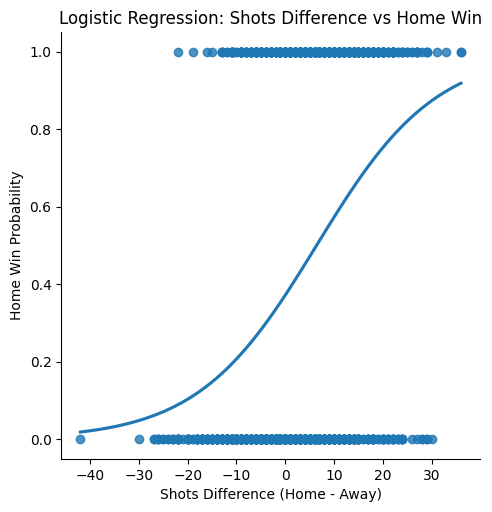

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Home win = 1, else = 0
seasonal_data['HomeWin'] = (seasonal_data['Winner'] == seasonal_data['HomeTeam']).astype(int)

sns.lmplot(x='Shots_Difference', y='HomeWin', data=seasonal_data, logistic=True, ci=None)
plt.xlabel('Shots Difference (Home - Away)')
plt.ylabel('Home Win Probability')
plt.title('Logistic Regression: Shots Difference vs Home Win')
plt.show()

In [28]:
seasonal_data.groupby('Season')['HomeTeam'].nunique()

Season
2021    18
2122    18
2223    18
2324    18
2425    18
Name: HomeTeam, dtype: int64

In [29]:
seasonal_data['Season'].value_counts()

Season
2021    306
2122    306
2223    306
2324    306
2425    306
Name: count, dtype: int64

In [30]:
seasonal_data['FTR'].value_counts()

FTR
H    666
A    496
D    368
Name: count, dtype: int64

In [31]:
#from the above statistics, it is evident that home teams win more frequently than away teams or draws.

In [32]:
seasonal_data[['FTHG', 'FTAG']].mean()

FTHG    1.673856
FTAG    1.356209
dtype: float64

In [33]:
goals = (
    seasonal_data.groupby('HomeTeam')['FTHG'].sum()
    + seasonal_data.groupby('AwayTeam')['FTAG'].sum()
)
print(goals.sort_values(ascending=False))

HomeTeam
PSV Eindhoven       463
Ajax                427
Feyenoord           389
AZ Alkmaar          335
Twente              300
Utrecht             269
Sparta Rotterdam    229
Heerenveen          219
Waalwijk            205
Nijmegen            199
For Sittard         199
Go Ahead Eagles     187
Vitesse             169
Heracles            158
Zwolle              158
Groningen           152
Willem II           106
Excelsior            82
Cambuur              79
Volendam             76
FC Emmen             73
Almere City          56
VVV Venlo            43
NAC Breda            34
Den Haag             29
dtype: int64


<Axes: xlabel='Season'>

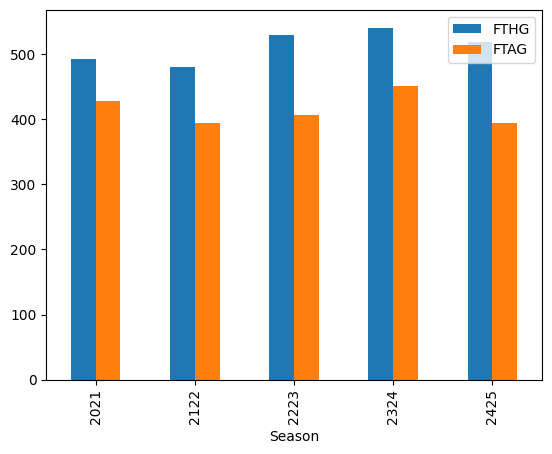

In [34]:
seasonal_data.groupby('Season')[['FTHG', 'FTAG']].sum().plot(kind='bar')

<Axes: xlabel='Season'>

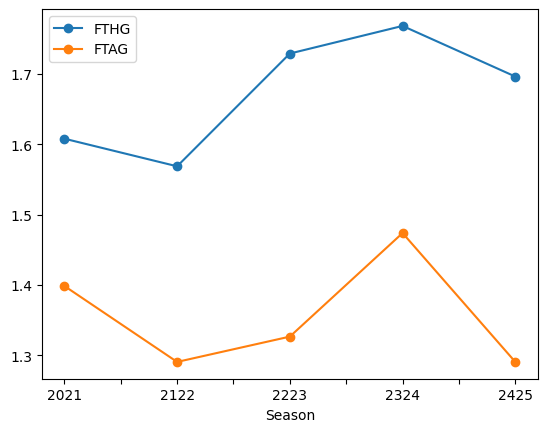

In [35]:
seasonal_data.groupby('Season')[['FTHG', 'FTAG']].mean().plot(marker='o')

C:\Users\Simon\AppData\Local\Temp\ipykernel_11548\279137342.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  seasonal_data['HomePointsPct'] = (seasonal_data['HomePoints'] / (seasonal_data['HomePoints'] + seasonal_data['AwayPoints'])) * 100


<Axes: title={'center': 'Average Home Points Percentage per Season'}, xlabel='Season'>

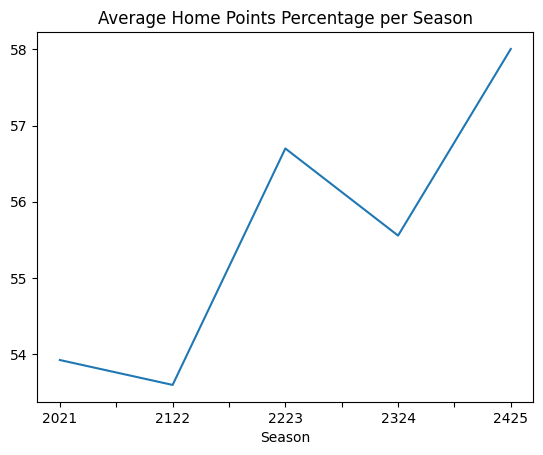

In [36]:
seasonal_data['HomePointsPct'] = (seasonal_data['HomePoints'] / (seasonal_data['HomePoints'] + seasonal_data['AwayPoints'])) * 100
home_points = seasonal_data.groupby('Season')['HomePointsPct'].mean()
home_points.plot(title='Average Home Points Percentage per Season')

In [37]:
seasonal_data.corr(numeric_only=True)

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,...,BFECAHH,BFECAHA,GoalDifference,HomePoints,AwayPoints,Shots_Difference,HomeWin,HomeWin_Prob,ShotsonTarget_Difference,HomePointsPct
FTHG,1.000000,-0.178388,0.718585,-0.082551,0.376266,-0.242786,0.629282,-0.225394,-0.127455,-0.111078,...,-0.172111,-0.047866,0.791854,0.667085,-0.613205,0.364169,0.656873,0.542491,0.544778,0.649055
FTAG,-0.178388,1.000000,-0.123500,0.687914,-0.230628,0.453657,-0.249691,0.658892,-0.005268,-0.049901,...,-0.034536,0.125002,-0.742172,-0.624607,0.670312,-0.391090,-0.531087,-0.507278,-0.548177,-0.655882
HTHG,0.718585,-0.123500,1.000000,-0.106275,0.184571,-0.136964,0.413420,-0.147843,-0.086376,-0.077558,...,-0.198548,-0.145639,0.566106,0.480604,-0.432998,0.188478,0.480919,0.356376,0.357767,0.463213
HTAG,-0.082551,0.687914,-0.106275,1.000000,-0.102774,0.233094,-0.142836,0.390127,0.004430,-0.001413,...,-0.048110,0.114511,-0.483193,-0.407233,0.433922,-0.191315,-0.348976,-0.293412,-0.321286,-0.426067
HS,0.376266,-0.230628,0.184571,-0.102774,1.000000,-0.476661,0.720526,-0.349558,-0.200018,-0.019224,...,-0.144876,-0.142058,0.399430,0.320045,-0.334297,0.875007,0.280132,0.668751,0.677106,0.331479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Shots_Difference,0.364169,-0.391090,0.188478,-0.191315,0.875007,-0.842657,0.648354,-0.630321,-0.142079,0.046139,...,-0.072241,-0.147623,0.490784,0.401481,-0.412089,1.000000,0.357759,0.770455,0.793393,0.412183
HomeWin,0.656873,-0.531087,0.480919,-0.348976,0.280132,-0.338072,0.448309,-0.424511,-0.055995,-0.025531,...,-0.091202,-0.011479,0.777047,0.960129,-0.820082,0.357759,1.000000,0.560761,0.541992,0.902878
HomeWin_Prob,0.542491,-0.507278,0.356376,-0.293412,0.668751,-0.655239,0.819257,-0.731247,-0.168205,-0.021673,...,-0.083848,-0.108946,0.684359,0.609788,-0.605993,0.770455,0.560761,1.000000,0.964500,0.616073
ShotsonTarget_Difference,0.544778,-0.548177,0.357767,-0.321286,0.677106,-0.687598,0.830866,-0.779056,-0.152070,-0.002296,...,-0.147036,-0.160603,0.711301,0.593782,-0.594725,0.793393,0.541992,0.964500,1.000000,0.602225


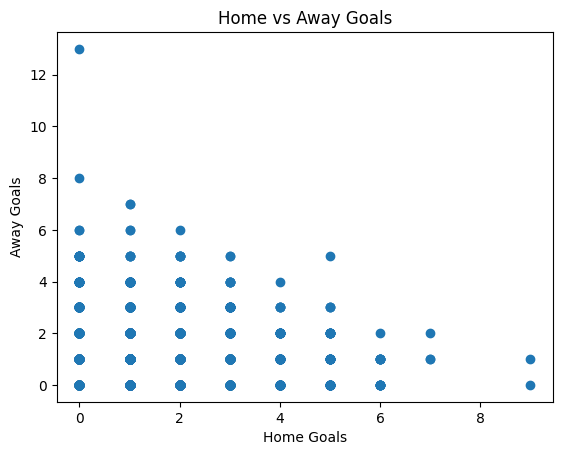

In [38]:
import matplotlib.pyplot as plt
plt.scatter(seasonal_data['FTHG'], seasonal_data['FTAG'])
plt.xlabel('Home Goals')
plt.ylabel('Away Goals')
plt.title('Home vs Away Goals')
plt.show()

In [39]:
avg_goals = seasonal_data.groupby('HomeTeam')['FTHG'].mean().sort_values(ascending=False)
print(avg_goals)


HomeTeam
PSV Eindhoven       2.952941
Ajax                2.811765
Feyenoord           2.352941
AZ Alkmaar          2.141176
Twente              2.035294
Go Ahead Eagles     1.705882
Nijmegen            1.647059
Utrecht             1.600000
Heracles            1.544118
Heerenveen          1.482353
Sparta Rotterdam    1.447059
Excelsior           1.411765
Waalwijk            1.376471
Volendam            1.323529
For Sittard         1.317647
Cambuur             1.264706
Vitesse             1.250000
FC Emmen            1.235294
NAC Breda           1.235294
Groningen           1.205882
VVV Venlo           1.176471
Willem II           1.176471
Zwolle              1.102941
Den Haag            1.000000
Almere City         0.911765
Name: FTHG, dtype: float64


In [40]:
defense = seasonal_data.groupby('AwayTeam')['FTHG'].mean().sort_values()
print(defense)

AwayTeam
Feyenoord           1.129412
Ajax                1.200000
PSV Eindhoven       1.200000
AZ Alkmaar          1.211765
Sparta Rotterdam    1.282353
Twente              1.317647
Nijmegen            1.397059
Utrecht             1.435294
Almere City         1.676471
Go Ahead Eagles     1.705882
Vitesse             1.720588
Heerenveen          1.823529
For Sittard         1.894118
Zwolle              1.970588
Waalwijk            1.976471
Willem II           1.980392
Groningen           2.029412
FC Emmen            2.029412
Heracles            2.058824
Cambuur             2.088235
NAC Breda           2.117647
Den Haag            2.235294
Volendam            2.441176
VVV Venlo           2.647059
Excelsior           2.676471
Name: FTHG, dtype: float64


In [41]:
team_stats = pd.DataFrame({
    'AvgGoalsScored': seasonal_data.groupby('HomeTeam')['FTHG'].mean(),
    'AvgGoalsConceded': seasonal_data.groupby('HomeTeam')['FTAG'].mean(),
})
print(team_stats)

                  AvgGoalsScored  AvgGoalsConceded
HomeTeam                                          
AZ Alkmaar              2.141176          1.094118
Ajax                    2.811765          0.835294
Almere City             0.911765          1.941176
Cambuur                 1.264706          2.000000
Den Haag                1.000000          2.235294
Excelsior               1.411765          1.558824
FC Emmen                1.235294          1.882353
Feyenoord               2.352941          0.800000
For Sittard             1.317647          1.600000
Go Ahead Eagles         1.705882          1.352941
Groningen               1.205882          1.205882
Heerenveen              1.482353          1.423529
Heracles                1.544118          1.455882
NAC Breda               1.235294          1.294118
Nijmegen                1.647059          1.455882
PSV Eindhoven           2.952941          0.882353
Sparta Rotterdam        1.447059          1.352941
Twente                  2.03529

C:\Users\Simon\AppData\Local\Temp\ipykernel_11548\3445689003.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  seasonal_data['GoalDiff'] = seasonal_data['FTHG'] - seasonal_data['FTAG']


<Axes: >

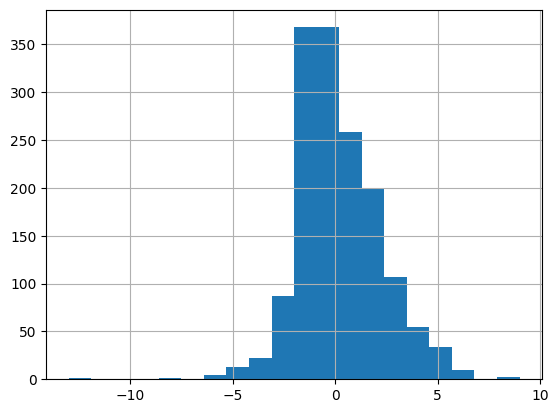

In [42]:
seasonal_data['GoalDiff'] = seasonal_data['FTHG'] - seasonal_data['FTAG']
seasonal_data['GoalDiff'].hist(bins=20)
#from this graph, it is interesting to see that if the away team wins, they win way more often by 1 goal than by 2 or more goals, whereas for the home team, it is a bit more spread. 

In [43]:
seasonal_data['TotalGoals'] = seasonal_data['FTHG'] + seasonal_data['FTAG']
print(seasonal_data.loc[seasonal_data['TotalGoals'].idxmax()])

Div                                 N1
Date                        24/10/2020
Time                             15:30
HomeTeam                     VVV Venlo
AwayTeam                          Ajax
                               ...    
HomeWin_Prob                  0.000095
ShotsonTarget_Difference           -23
HomePointsPct                      0.0
GoalDiff                           -13
TotalGoals                          13
Name: 44, Length: 143, dtype: object


C:\Users\Simon\AppData\Local\Temp\ipykernel_11548\3685546239.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  seasonal_data['TotalGoals'] = seasonal_data['FTHG'] + seasonal_data['FTAG']


In [44]:
# Create conditions for when home or away team is leading at half time
seasonal_data['HT_leader'] = seasonal_data.apply(
    lambda x: 'Home' if x['HTHG'] > x['HTAG'] else ('Away' if x['HTHG'] < x['HTAG'] else 'Draw'),
    axis=1
)

# For each team, compute % of wins when leading at half time
# 1️⃣ Home teams
home_leads = seasonal_data[seasonal_data['HT_leader'] == 'Home'].groupby('HomeTeam').agg(
    games_leading=('HomeTeam', 'count'),
    wins_when_leading=('FTR', lambda x: (x == 'H').sum())
)
home_leads['home_win_pct_when_leading_HT'] = 100 * home_leads['wins_when_leading'] / home_leads['games_leading']

# 2️⃣ Away teams
away_leads = seasonal_data[seasonal_data['HT_leader'] == 'Away'].groupby('AwayTeam').agg(
    games_leading=('AwayTeam', 'count'),
    wins_when_leading=('FTR', lambda x: (x == 'A').sum())
)
away_leads['away_win_pct_when_leading_HT'] = 100 * away_leads['wins_when_leading'] / away_leads['games_leading']

# Combine into one dataframe per team
team_win_pct = pd.concat([home_leads['home_win_pct_when_leading_HT'], 
                          away_leads['away_win_pct_when_leading_HT']], axis=1).fillna(0)

team_win_pct['overall_win_pct_when_leading_HT'] = (
    (home_leads['wins_when_leading'].fillna(0) + away_leads['wins_when_leading'].fillna(0)) /
    (home_leads['games_leading'].fillna(0) + away_leads['games_leading'].fillna(0))
) * 100

# Sort descending for clarity
team_win_pct = team_win_pct.sort_values('overall_win_pct_when_leading_HT', ascending=False)

team_win_pct

C:\Users\Simon\AppData\Local\Temp\ipykernel_11548\3602024245.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  seasonal_data['HT_leader'] = seasonal_data.apply(


,home_win_pct_when_leading_HT,away_win_pct_when_leading_HT,overall_win_pct_when_leading_HT
PSV Eindhoven,98.148148,78.571429,89.583333
Feyenoord,84.615385,89.189189,86.842105
Ajax,87.500000,81.818182,85.000000
AZ Alkmaar,85.000000,76.470588,81.081081
Sparta Rotterdam,76.000000,84.000000,80.000000
Groningen,83.333333,69.230769,77.419355
Twente,83.720930,66.666667,76.712329
Go Ahead Eagles,84.000000,58.333333,75.675676
Vitesse,78.947368,70.588235,75.000000
Nijmegen,66.666667,77.777778,72.727273


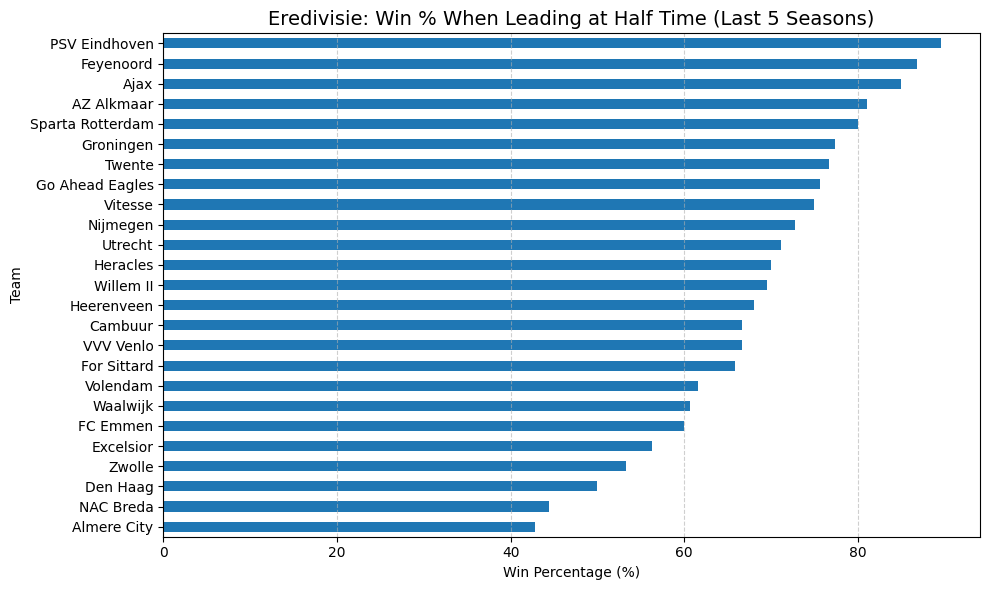

In [45]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
team_win_pct['overall_win_pct_when_leading_HT'].sort_values().plot(kind='barh')

plt.title('Eredivisie: Win % When Leading at Half Time (Last 5 Seasons)', fontsize=14)
plt.xlabel('Win Percentage (%)')
plt.ylabel('Team')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\Simon\AppData\Local\Temp\ipykernel_11548\2346593735.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


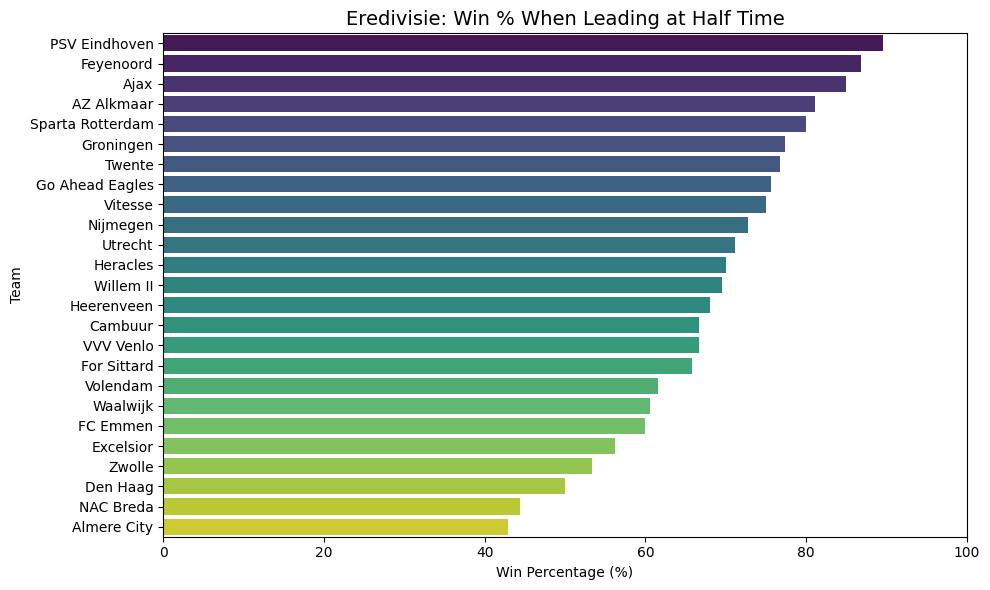

In [46]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x='overall_win_pct_when_leading_HT',
    y=team_win_pct.index,
    data=team_win_pct.reset_index(),
    palette='viridis'
)

plt.title('Eredivisie: Win % When Leading at Half Time', fontsize=14)
plt.xlabel('Win Percentage (%)')
plt.ylabel('Team')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

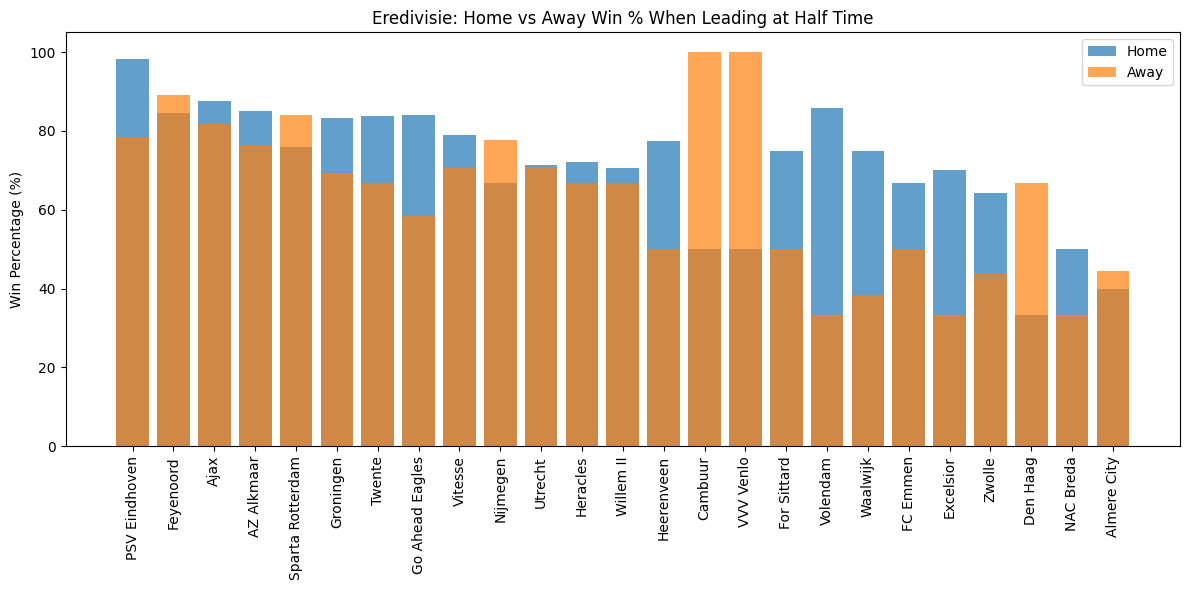

In [47]:
team_win_pct_sorted = team_win_pct.sort_values('overall_win_pct_when_leading_HT', ascending=False).reset_index()

plt.figure(figsize=(12,6))
plt.bar(team_win_pct_sorted['HomeTeam'] if 'HomeTeam' in team_win_pct_sorted.columns else team_win_pct_sorted['index'], 
        team_win_pct_sorted['home_win_pct_when_leading_HT'], label='Home', alpha=0.7)
plt.bar(team_win_pct_sorted['index'], 
        team_win_pct_sorted['away_win_pct_when_leading_HT'], label='Away', alpha=0.7)

plt.title('Eredivisie: Home vs Away Win % When Leading at Half Time')
plt.ylabel('Win Percentage (%)')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


In [48]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'vscode'

team_win_pct_sorted = team_win_pct.sort_values('overall_win_pct_when_leading_HT', ascending=False).reset_index()
team_names = team_win_pct_sorted['index']

win_fig = go.Figure(data=[
    go.Bar(
        name='Home',
        x=team_names,
        y=team_win_pct_sorted['home_win_pct_when_leading_HT'],
        marker_color='royalblue',
        hovertemplate='<b>%{x}</b><br>Home Win %: %{y:.1f}%<extra></extra>'
    ),
    go.Bar(
        name='Away',
        x=team_names,
        y=team_win_pct_sorted['away_win_pct_when_leading_HT'],
        marker_color='orange',
        hovertemplate='<b>%{x}</b><br>Away Win %: %{y:.1f}%<extra></extra>'
    )
])

win_fig.update_layout(
    title='Eredivisie: Home vs Away Win % When Leading at Half Time (Interactive)',
    xaxis_title='Team',
    yaxis_title='Win Percentage (%)',
    barmode='group',
    hovermode='x unified',
    template='plotly_white',
    xaxis_tickangle=-45,
    height=600
)

win_fig.show()


In [49]:


# Identify who was leading at half time
seasonal_data['HT_leader'] = seasonal_data.apply(
    lambda x: 'Home' if x['HTHG'] > x['HTAG'] else ('Away' if x['HTHG'] < x['HTAG'] else 'Draw'),
    axis=1
)

home_losing = seasonal_data[seasonal_data['HT_leader'] == 'Away'].groupby('HomeTeam').agg(
    games_trailing=('HomeTeam', 'count'),
    losses_when_trailing=('FTR', lambda x: (x == 'A').sum())  # Home loss = 'A'
)
home_losing['home_loss_pct_when_losing_HT'] = (
    100 * home_losing['losses_when_trailing'] / home_losing['games_trailing']
)

away_losing = seasonal_data[seasonal_data['HT_leader'] == 'Home'].groupby('AwayTeam').agg(
    games_trailing=('AwayTeam', 'count'),
    losses_when_trailing=('FTR', lambda x: (x == 'H').sum())  # Away loss = 'H'
)
away_losing['away_loss_pct_when_losing_HT'] = (
    100 * away_losing['losses_when_trailing'] / away_losing['games_trailing']
)

team_loss_pct = pd.concat([
    home_losing['home_loss_pct_when_losing_HT'], 
    away_losing['away_loss_pct_when_losing_HT']
], axis=1).fillna(0)

team_loss_pct['overall_loss_pct_when_losing_HT'] = (
    (home_losing['losses_when_trailing'].fillna(0) + away_losing['losses_when_trailing'].fillna(0)) /
    (home_losing['games_trailing'].fillna(0) + away_losing['games_trailing'].fillna(0))
) * 100

team_loss_pct = team_loss_pct.sort_values('overall_loss_pct_when_losing_HT', ascending=False)

team_loss_pct.head()



,home_loss_pct_when_losing_HT,away_loss_pct_when_losing_HT,overall_loss_pct_when_losing_HT
Almere City,92.307692,100.000000,96.428571
Den Haag,88.888889,100.000000,93.333333
Volendam,92.307692,94.117647,93.333333
Cambuur,100.000000,80.000000,89.285714
Excelsior,85.714286,87.500000,86.956522


In [50]:
import plotly.graph_objects as go
import plotly.io as pio

# Renderer setup for VS Code
pio.renderers.default = 'vscode'

# Sort for plotting
team_loss_pct_sorted = team_loss_pct.sort_values('overall_loss_pct_when_losing_HT', ascending=False).reset_index()
team_names = team_loss_pct_sorted['index']

# Create grouped bar chart
loss_fig = go.Figure(data=[
    go.Bar(
        name='Home (Losing at HT)',
        x=team_names,
        y=team_loss_pct_sorted['home_loss_pct_when_losing_HT'],
        marker_color='crimson',
        hovertemplate='<b>%{x}</b><br>Home Loss %: %{y:.1f}%<extra></extra>'
    ),
    go.Bar(
        name='Away (Losing at HT)',
        x=team_names,
        y=team_loss_pct_sorted['away_loss_pct_when_losing_HT'],
        marker_color='darkorange',
        hovertemplate='<b>%{x}</b><br>Away Loss %: %{y:.1f}%<extra></extra>'
    )
])

# Layout customization
loss_fig.update_layout(
    title='Eredivisie: Loss % When Losing at Half Time (Last 5 Seasons)',
    xaxis_title='Team',
    yaxis_title='Loss Percentage (%)',
    barmode='group',
    hovermode='x unified',
    template='plotly_white',
    xaxis_tickangle=-45,
    height=600
)

# Display the chart inline in VS Code
loss_fig.show()


In [51]:
import pickle

# Assuming your figures are called win_fig and loss_fig
with open("win_fig.pkl", "wb") as f:
    pickle.dump(win_fig, f)

with open("loss_fig.pkl", "wb") as f:
    pickle.dump(loss_fig, f)


In [52]:
#computing match differences
# Create difference variables
merged['ShotDiff'] = merged['HS'] - merged['AS']
merged['ShotOnTargetDiff'] = merged['HST'] - merged['AST']
merged['CornerDiff'] = merged['HC'] - merged['AC']
merged['HomeWin'] = merged['FTR'].apply(lambda x: 1 if x == 'H' else 0)


In [53]:
print(merged.columns)

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       'BFECA', 'BFEC>2.5', 'BFEC<2.5', 'BFECAHH', 'BFECAHA', 'FullTimeScore',
       'ShotDiff', 'ShotOnTargetDiff', 'CornerDiff', 'HomeWin'],
      dtype='object', length=137)


In [54]:
merged['cornerdiff'] = merged['HC'] - merged['AC']

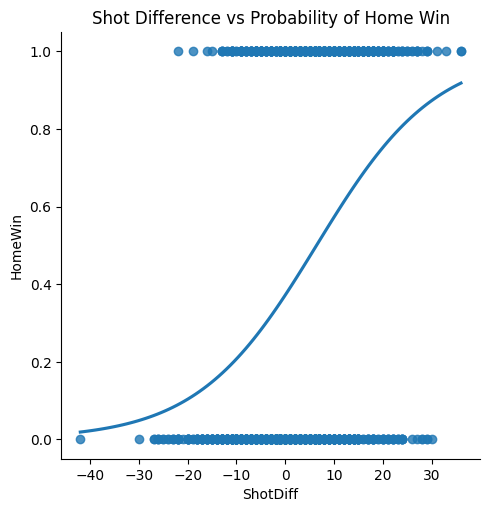

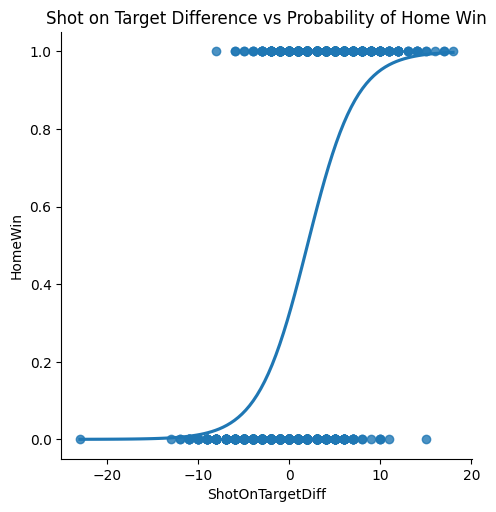

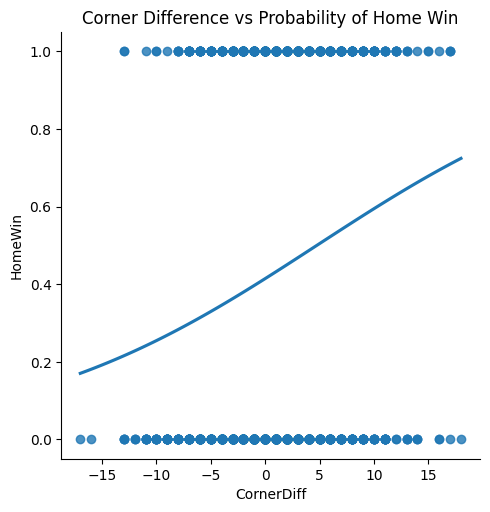

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(data=merged, x='ShotDiff', y='HomeWin', logistic=True, ci=None)
plt.title('Shot Difference vs Probability of Home Win')

sns.lmplot(data=merged, x='ShotOnTargetDiff', y='HomeWin', logistic=True, ci=None)
plt.title('Shot on Target Difference vs Probability of Home Win')

sns.lmplot(data=merged, x='CornerDiff', y='HomeWin', logistic=True, ci=None)
plt.title('Corner Difference vs Probability of Home Win')

plt.show()


In [56]:
#shot dominance graph
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

merged['ShotDiff'] = merged['HS'] - merged['AS']
merged['ShotOnTargetDiff'] = merged['HST'] - merged['AST']
merged['TotalShots'] = merged['HS'] + merged['AS']
merged['HomeWin'] = merged['FTR'].apply(lambda x: 1 if x == 'H' else 0)

X = merged[['ShotDiff', 'ShotOnTargetDiff']]
y = merged['HomeWin']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LogisticRegression()
model.fit(X_scaled, y)

x_range = np.linspace(X['ShotDiff'].min(), X['ShotDiff'].max(), 200)
y_range = np.linspace(X['ShotOnTargetDiff'].min(), X['ShotOnTargetDiff'].max(), 200)
xx, yy = np.meshgrid(x_range, y_range)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(scaler.transform(grid))[:, 1].reshape(xx.shape)

contour = go.Contour(
    x=x_range,
    y=y_range,
    z=probs,
    colorscale='RdYlGn',
    opacity=0.9,
    contours=dict(showlines=False),
    colorbar=dict(title='Home Win<br>Probability', tickformat='.0%'),
)

bubbles = go.Scatter(
    x=merged['ShotDiff'],
    y=merged['ShotOnTargetDiff'],
    mode='markers',
    marker=dict(
        size=np.sqrt(merged['TotalShots']) * 1.8,  # bigger bubble for more shots
        color=merged['HomeWin'],
        colorscale='RdYlGn',
        line=dict(width=1, color='white'),
        opacity=0.85,
        cmin=0,
        cmax=1,
        showscale=False
    ),
    text=[
        f"<b>{ht} vs {at}</b><br>"
        f"Shots: {hs}-{as_}<br>"
        f"On Target: {hst}-{ast}<br>"
        f"Full-time score: {fts}<br>"
        f"Result: {res}"
        for ht, at, hs, as_, hst, ast, fts, res in zip(
            merged['HomeTeam'],
            merged['AwayTeam'],
            merged['HS'],
            merged['AS'],
            merged['HST'],
            merged['AST'],
            merged['FullTimeScore'],
            merged['FTR']
        )
    ],
    hoverinfo='text'
)

boundary = go.Contour(
    x=x_range,
    y=y_range,
    z=probs,
    contours=dict(
        start=0.5, end=0.5, size=0.01, coloring='lines', showlabels=False
    ),
    showscale=False,
    line=dict(color='black', width=3, dash='dot'),
    hoverinfo='skip'
)

layout = go.Layout(
    title=dict(
        text="🏟️ <b>Match Dominance Arena:</b> Shots vs Shots on Target and Home Win Probability",
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title='Shot Difference (Home − Away)',
        zeroline=True, zerolinecolor='gray', gridcolor='rgba(200,200,200,0.3)'
    ),
    yaxis=dict(
        title='Shots on Target Difference (Home − Away)',
        zeroline=True, zerolinecolor='gray', gridcolor='rgba(200,200,200,0.3)'
    ),
    paper_bgcolor='rgb(245,245,245)',
    plot_bgcolor='rgb(250,250,250)',
    hovermode='closest',
    height=700,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig = go.Figure(data=[contour, boundary, bubbles], layout=layout)
fig.show()

with open("match_dominance_fig.pkl", "wb") as f:
    pickle.dump(fig, f)

c:\Users\Simon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [57]:
import plotly.express as px
fig = px.scatter(
    merged, 
    x='CornerDiff', 
    y='HomeWin',
    title='Corner Difference vs Home Win',
    labels={'CornerDiff': 'Corner Difference (Home - Away)', 'HomeWin': 'Home Win (1=yes, 0=no)'},
    opacity=0.7,
    color='HomeWin'
)

fig.show()

In [58]:
merged['HomeWin'] = merged['FTR'].apply(lambda x: 1 if x == 'H' else 0)
X = merged[['HC', 'AC']]
y = merged['HomeWin']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LogisticRegression()
model.fit(X_scaled, y)

hc_range = np.linspace(merged['HC'].min(), merged['HC'].max(), 200)
ac_range = np.linspace(merged['AC'].min(), merged['AC'].max(), 200)
xx, yy = np.meshgrid(hc_range, ac_range)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(scaler.transform(grid))[:, 1].reshape(xx.shape)

heatmap = go.Contour(
    x=hc_range,
    y=ac_range,
    z=probs,
    colorscale="RdYlGn",
    opacity=0.85,
    colorbar=dict(title="🏠 Home Win Probability", tickformat=".0%"),
    contours=dict(showlines=False)
)

matches = go.Scatter(
    x=merged['HC'],
    y=merged['AC'],
    mode='markers',
    marker=dict(
        size=8,
        color=merged['HomeWin'],
        colorscale="RdYlGn",
        line=dict(width=1, color='white'),
        opacity=0.85,
        cmin=0, cmax=1,
        showscale=False
    ),
    text=[
        f"<b>{ht}</b> vs <b>{at}</b><br>"
        f"Full-time score: {fts}<br>"
        f"Corners: {hc}-{ac}<br>"
        f"Result: {res}"
        for ht, at, hc, ac, fts, res in zip(
            merged['HomeTeam'],
            merged['AwayTeam'],
            merged['HC'],
            merged['AC'],
            merged['FullTimeScore'],
            merged['FTR']
        )
    ],
    hoverinfo='text',
    name="Matches"
)

layout = go.Layout(
    title=dict(
        text="<b>Home vs Away Corners — Home Win Probability Map</b>",
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(title="Home Corners (HC)"),
    yaxis=dict(title="Away Corners (AC)"),
    template='plotly_white',
    paper_bgcolor='rgb(245,245,245)',
    plot_bgcolor='rgb(250,250,250)',
    hovermode='closest',
    height=700
)

fig = go.Figure(data=[heatmap, matches], layout=layout)
fig.show()

with open("corner_heatmap_fig.pkl", "wb") as f:
    pickle.dump(fig, f)


c:\Users\Simon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Define predictors
diff_features = ['CornerDiff', 'ShotDiff', 'ShotOnTargetDiff']

results = {}

for feature in diff_features:
    X = merged[[feature]]
    y = merged['HomeWin']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[feature] = {'Accuracy': acc, 'AUC': auc}
    print(f"\n📊 {feature} Regression:")
    print(f"Accuracy: {acc:.3f}")
    print(f"AUC: {auc:.3f}")


📊 CornerDiff Regression:
Accuracy: 0.588
AUC: 0.629

📊 ShotDiff Regression:
Accuracy: 0.673
AUC: 0.729

📊 ShotOnTargetDiff Regression:
Accuracy: 0.732
AUC: 0.823


In [60]:
import numpy as np

# Small random jitter to separate overlapping points
jitter_strength = 0.15  # adjust if needed
x_jitter = merged['HC'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(merged))
y_jitter = merged['AC'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(merged))

matches = go.Scatter(
    x=x_jitter,
    y=y_jitter,
    mode='markers',
    marker=dict(
        size=8,
        color=merged['HomeWin'],
        colorscale="RdYlGn",
        line=dict(width=0.8, color='white'),
        opacity=0.7,
        cmin=0, cmax=1,
        showscale=False
    ),
    text=[
        f"<b>{ht}</b> vs <b>{at}</b><br>"
        f"Full-time score: {fts}<br>"
        f"Corners: {hc}-{ac}<br>"
        f"Result: {res}"
        for ht, at, hc, ac, fts, res in zip(
            merged['HomeTeam'],
            merged['AwayTeam'],
            merged['HC'],
            merged['AC'],
            merged['FullTimeScore'],
            merged['FTR']
        )
    ],
    hoverinfo='text',
    name="Matches"
)


In [61]:
density = go.Histogram2d(
    x=merged['HC'],
    y=merged['AC'],
    colorscale='Blues',
    showscale=True,
    opacity=0.5,
    name='Match Density'
)
fig = go.Figure(data=[heatmap, density, matches], layout=layout)
fig.show()

In [62]:
# Calculate home win rate for each corner combination
win_rate = merged.groupby(['HC', 'AC'])['HomeWin'].mean().reset_index()

fig_cornersDutch = go.Figure(data=go.Heatmap(
    x=win_rate['HC'],
    y=win_rate['AC'],
    z=win_rate['HomeWin'],
    colorscale='RdYlGn',
    colorbar=dict(title="Home Win Rate", tickformat=".0%"),
))

fig_cornersDutch.update_layout(
    title="Home Win Probability by Corner Combination",
    xaxis_title="Home Corners (HC)",
    yaxis_title="Away Corners (AC)",
    template="plotly_white"
)

fig_cornersDutch.show()


with open("corner_heatmap_fig.pkl", "wb") as f:
    pickle.dump(fig_cornersDutch, f)

In [63]:
#computing average points
merged['HomePoints'] = merged['FTR'].apply(lambda x: 3 if x == 'H' else (1 if x == 'D' else 0))
merged['AwayPoints'] = merged['FTR'].apply(lambda x: 3 if x == 'A' else (1 if x == 'D' else 0))

avg_homepoints = merged.groupby('HomeTeam')['HomePoints'].mean().sort_values(ascending=False)
avg_awaypoints = merged.groupby('AwayTeam')['AwayPoints'].mean().sort_values(ascending=False)
print(avg_homepoints)

HomeTeam
PSV Eindhoven       2.576471
Ajax                2.317647
Feyenoord           2.200000
Twente              2.035294
AZ Alkmaar          2.000000
Utrecht             1.682353
Go Ahead Eagles     1.588235
Heracles            1.485294
Heerenveen          1.435294
NAC Breda           1.411765
Sparta Rotterdam    1.341176
Vitesse             1.338235
Excelsior           1.323529
For Sittard         1.282353
Groningen           1.279412
Waalwijk            1.247059
Nijmegen            1.235294
Zwolle              1.191176
Volendam            1.147059
Willem II           1.098039
FC Emmen            1.000000
Almere City         0.794118
Cambuur             0.794118
VVV Venlo           0.764706
Den Haag            0.529412
Name: HomePoints, dtype: float64


In [64]:
merged = merged.merge(avg_homepoints.rename('AvgHomePoints'), left_on='HomeTeam', right_index=True)
merged = merged.merge(avg_awaypoints.rename('AvgAwayPoints'), left_on='AwayTeam', right_index=True)

In [65]:
merged['Date'] = pd.to_datetime(merged['Date'], dayfirst=True)

def get_season(date):
    year = date.year
    if date.month >= 7:  # July or later → season starts this year
        return f"{year}/{year+1}"
    else:  # Jan-Jun → season started last year
        return f"{year-1}/{year}"

merged['Season'] = merged['Date'].apply(get_season)
merged = merged[merged['Season'].isin(['2020/2021', '2021/2022', '2022/2023', '2023/2024', '2024/2025'])]
merged = merged.merge(
    merged.groupby('Season').agg(
        AvgHomePointsSeason=('HomePoints', 'mean'),
        AvgAwayPointsSeason=('AwayPoints', 'mean')
    ),
    left_on='Season',
    right_index=True
)

In [66]:
merged.columns

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       'CornerDiff', 'HomeWin', 'cornerdiff', 'TotalShots', 'HomePoints',
       'AwayPoints', 'AvgHomePoints', 'AvgAwayPoints', 'AvgHomePointsSeason',
       'AvgAwayPointsSeason'],
      dtype='object', length=145)

In [67]:
merged[['Season', 'AvgHomePoints', 'AvgAwayPoints', 'AvgHomePointsSeason', 'AvgAwayPointsSeason']].head()

,Season,AvgHomePoints,AvgAwayPoints,AvgHomePointsSeason,AvgAwayPointsSeason
0,2020/2021,1.435294,0.666667,1.490196,1.254902
1,2020/2021,1.191176,2.082353,1.490196,1.254902
2,2020/2021,2.035294,0.964706,1.490196,1.254902
3,2020/2021,1.000000,0.588235,1.490196,1.254902
4,2020/2021,1.485294,0.764706,1.490196,1.254902


In [68]:
#computing new table containing average points data
overall_homepoints = merged.groupby('HomeTeam')['HomePoints'].mean().rename('Overall_AvgHome')
overall_awaypoints = merged.groupby('AwayTeam')['AwayPoints'].mean().rename('Overall_AvgAway')

overall_total = (
    pd.concat([
        merged.rename(columns={'HomeTeam' : 'Team'})[['Team', 'HomePoints']].rename(columns={'HomePoints' : 'Points'}),
        merged.rename(columns={'AwayTeam' : 'Team'})[['Team', 'AwayPoints']].rename(columns={'AwayPoints' : 'Points'})
    ])
    .groupby('Team')['Points'].mean()
    .rename('Overall_AvgTotal')
) 
overall = pd.concat([overall_homepoints, overall_awaypoints, overall_total], axis=1).reset_index()
overall = overall.rename(columns={'index':'Team'})

In [69]:
#per season average points
season_home = (
    merged.groupby(['Season','HomeTeam'])['HomePoints']
    .mean()
    .rename('TeamSeason_AvgHome')
    .reset_index()
    .rename(columns={'HomeTeam':'Team'})
)

season_away = (
    merged.groupby(['Season','AwayTeam'])['AwayPoints']
    .mean()
    .rename('TeamSeason_AvgAway')
    .reset_index()
    .rename(columns={'AwayTeam':'Team'})
)

season_total = pd.concat([
    merged.assign(Team=merged['HomeTeam'], Points=merged['HomePoints'])[['Season','Team','Points']],
    merged.assign(Team=merged['AwayTeam'], Points=merged['AwayPoints'])[['Season','Team','Points']]
]).groupby(['Season','Team'])['Points'].mean().rename('TeamSeason_AvgTotal').reset_index()

team_season_df = season_home.merge(season_away, on=['Season','Team'], how='outer')
team_season_df = team_season_df.merge(season_total, on=['Season','Team'], how='outer')

team_season_wide = team_season_df.pivot_table(
    index='Team',
    columns='Season',
    values=['TeamSeason_AvgHome','TeamSeason_AvgAway','TeamSeason_AvgTotal'],
    aggfunc='first'  
)

team_season_wide.columns = [f"{metric}_{season}" for (metric, season) in team_season_wide.columns]
team_season_wide = team_season_wide.reset_index()

team_season_wide.head()


,Team,TeamSeason_AvgAway_2020/2021,TeamSeason_AvgAway_2021/2022,TeamSeason_AvgAway_2022/2023,TeamSeason_AvgAway_2023/2024,TeamSeason_AvgAway_2024/2025,TeamSeason_AvgHome_2020/2021,TeamSeason_AvgHome_2021/2022,TeamSeason_AvgHome_2022/2023,TeamSeason_AvgHome_2023/2024,TeamSeason_AvgHome_2024/2025,TeamSeason_AvgTotal_2020/2021,TeamSeason_AvgTotal_2021/2022,TeamSeason_AvgTotal_2022/2023,TeamSeason_AvgTotal_2023/2024,TeamSeason_AvgTotal_2024/2025
0,AZ Alkmaar,1.941176,1.470588,2.058824,1.705882,1.705882,2.235294,2.117647,1.882353,2.117647,1.647059,2.088235,1.794118,1.970588,1.911765,1.676471
1,Ajax,2.588235,2.352941,2.000000,1.352941,2.117647,2.588235,2.529412,2.058824,1.941176,2.470588,2.588235,2.441176,2.029412,1.647059,2.294118
2,Almere City,NaN,NaN,NaN,1.058824,0.647059,NaN,NaN,NaN,0.941176,0.647059,NaN,NaN,NaN,1.000000,0.647059
3,Cambuur,NaN,1.235294,0.588235,NaN,NaN,NaN,1.058824,0.529412,NaN,NaN,NaN,1.147059,0.558824,NaN,NaN
4,Den Haag,0.764706,NaN,NaN,NaN,NaN,0.529412,NaN,NaN,NaN,NaN,0.647059,NaN,NaN,NaN,NaN


In [70]:
overall.columns

Index(['Team', 'Overall_AvgHome', 'Overall_AvgAway', 'Overall_AvgTotal'], dtype='object')

In [71]:
final_table = pd.merge(overall, team_season_wide, on='Team', how='left')
final_table = final_table.sort_values('Team').reset_index(drop=True)
final_table.fillna(0, inplace=True)
final_table.head() 

,Team,Overall_AvgHome,Overall_AvgAway,Overall_AvgTotal,TeamSeason_AvgAway_2020/2021,TeamSeason_AvgAway_2021/2022,TeamSeason_AvgAway_2022/2023,TeamSeason_AvgAway_2023/2024,TeamSeason_AvgAway_2024/2025,TeamSeason_AvgHome_2020/2021,TeamSeason_AvgHome_2021/2022,TeamSeason_AvgHome_2022/2023,TeamSeason_AvgHome_2023/2024,TeamSeason_AvgHome_2024/2025,TeamSeason_AvgTotal_2020/2021,TeamSeason_AvgTotal_2021/2022,TeamSeason_AvgTotal_2022/2023,TeamSeason_AvgTotal_2023/2024,TeamSeason_AvgTotal_2024/2025
0,AZ Alkmaar,2.000000,1.776471,1.888235,1.941176,1.470588,2.058824,1.705882,1.705882,2.235294,2.117647,1.882353,2.117647,1.647059,2.088235,1.794118,1.970588,1.911765,1.676471
1,Ajax,2.317647,2.082353,2.200000,2.588235,2.352941,2.000000,1.352941,2.117647,2.588235,2.529412,2.058824,1.941176,2.470588,2.588235,2.441176,2.029412,1.647059,2.294118
2,Almere City,0.794118,0.852941,0.823529,0.000000,0.000000,0.000000,1.058824,0.647059,0.000000,0.000000,0.000000,0.941176,0.647059,0.000000,0.000000,0.000000,1.000000,0.647059
3,Cambuur,0.794118,0.911765,0.852941,0.000000,1.235294,0.588235,0.000000,0.000000,0.000000,1.058824,0.529412,0.000000,0.000000,0.000000,1.147059,0.558824,0.000000,0.000000
4,Den Haag,0.529412,0.764706,0.647059,0.764706,0.000000,0.000000,0.000000,0.000000,0.529412,0.000000,0.000000,0.000000,0.000000,0.647059,0.000000,0.000000,0.000000,0.000000


In [72]:
season_home = merged.groupby(['Season','HomeTeam'])['HomePoints'].mean().rename('Season_AvgHome').reset_index()
season_away = merged.groupby(['Season','AwayTeam'])['AwayPoints'].mean().rename('Season_AvgAway').reset_index()

season_total = (
    pd.concat([
        merged.assign(Team=merged['HomeTeam'], Points=merged['HomePoints'])[['Season', 'Team', 'Points']],
        merged.assign(Team=merged['AwayTeam'], Points=merged['AwayPoints'])[['Season', 'Team', 'Points']]
    ])
    .groupby(['Season', 'Team'])['Points'].mean().rename('Season_AvgTotal').reset_index()
)

season = pd.concat([season_home, season_away, season_total], axis=1).reset_index()

season = pd.merge(season_home, season_away, left_on=['Season','HomeTeam'], right_on=['Season','AwayTeam'], how='outer')
season = pd.merge(season, season_total, left_on=['Season', 'HomeTeam'], right_on=['Season', 'Team'], how='outer')

season['Team'] = season['HomeTeam'].fillna(season['AwayTeam']).fillna(season['Team'])

season = season[['Season', 'Team', 'Season_AvgHome', 'Season_AvgAway', 'Season_AvgTotal']]

season_wide = season.pivot(index='Team', columns='Season')
season_wide.columns = [f"{season}_{metric}" for (metric, season) in season_wide.columns]
season_wide = season_wide.reset_index()

final_table = pd.merge(overall, season_wide, on='Team', how='left')
print(final_table)

                Team  Overall_AvgHome  Overall_AvgAway  Overall_AvgTotal  \
0         AZ Alkmaar         2.000000         1.776471          1.888235   
1               Ajax         2.317647         2.082353          2.200000   
2        Almere City         0.794118         0.852941          0.823529   
3            Cambuur         0.794118         0.911765          0.852941   
4           Den Haag         0.529412         0.764706          0.647059   
5          Excelsior         1.323529         0.470588          0.897059   
6           FC Emmen         1.000000         0.705882          0.852941   
7          Feyenoord         2.200000         2.082353          2.141176   
8        For Sittard         1.282353         0.964706          1.123529   
9    Go Ahead Eagles         1.588235         0.955882          1.272059   
10         Groningen         1.279412         0.823529          1.051471   
11        Heerenveen         1.435294         0.988235          1.211765   
12          

In [73]:
season_home = season_home.rename(columns={'HomeTeam':'Team'})
season_away = season_away.rename(columns={'AwayTeam':'Team'})

season_ha = pd.merge(season_home, season_away, on=['Season','Team'], how='outer')
season = pd.merge(season_ha, season_total, on=['Season','Team'], how='outer')

season_wide = season.pivot(index='Team', columns='Season')
season_wide.columns = [f"{metric}_{season}" for (metric, season) in season_wide.columns]
season_wide = season_wide.reset_index()
final_table = pd.merge(overall, season_wide, on='Team', how='left')
final_table = final_table.fillna(0)
print(final_table)
final_table.to_excel('Eredivisie_Team_AvgPoints.xlsx', index=False)

                Team  Overall_AvgHome  Overall_AvgAway  Overall_AvgTotal  \
0         AZ Alkmaar         2.000000         1.776471          1.888235   
1               Ajax         2.317647         2.082353          2.200000   
2        Almere City         0.794118         0.852941          0.823529   
3            Cambuur         0.794118         0.911765          0.852941   
4           Den Haag         0.529412         0.764706          0.647059   
5          Excelsior         1.323529         0.470588          0.897059   
6           FC Emmen         1.000000         0.705882          0.852941   
7          Feyenoord         2.200000         2.082353          2.141176   
8        For Sittard         1.282353         0.964706          1.123529   
9    Go Ahead Eagles         1.588235         0.955882          1.272059   
10         Groningen         1.279412         0.823529          1.051471   
11        Heerenveen         1.435294         0.988235          1.211765   
12          

In [74]:
print(final_table.columns.tolist())

['Team', 'Overall_AvgHome', 'Overall_AvgAway', 'Overall_AvgTotal', 'Season_AvgHome_2020/2021', 'Season_AvgHome_2021/2022', 'Season_AvgHome_2022/2023', 'Season_AvgHome_2023/2024', 'Season_AvgHome_2024/2025', 'Season_AvgAway_2020/2021', 'Season_AvgAway_2021/2022', 'Season_AvgAway_2022/2023', 'Season_AvgAway_2023/2024', 'Season_AvgAway_2024/2025', 'Season_AvgTotal_2020/2021', 'Season_AvgTotal_2021/2022', 'Season_AvgTotal_2022/2023', 'Season_AvgTotal_2023/2024', 'Season_AvgTotal_2024/2025']


In [75]:
merged['Season'].value_counts()

Season
2020/2021    306
2021/2022    306
2022/2023    306
2023/2024    306
2024/2025    306
Name: count, dtype: int64

In [76]:
#computing weighted probabilities of winning, assuming that 50% of probability is determined by overall performance, and 50% by season performance
seasons = ['2020/2021','2021/2022','2022/2023','2023/2024','2024/2025']

for season in seasons:
    final_table[f'WeightedScore_{season}'] = (
        0.5 * final_table['Overall_AvgTotal'] +
        0.5 * final_table[f'Season_AvgTotal_{season}']
    )
    final_table[f'WinProb_{season}'] = (
        final_table[f'WeightedScore_{season}'] / final_table[f'WeightedScore_{season}'].sum()
    )


In [77]:
season = '2024/2025'

# Weighted total points per game
final_table['WeightedPPG'] = 0.5 * final_table['Overall_AvgTotal'] + 0.5 * final_table[f'Season_AvgTotal_{season}']

# Merge home team strength
merged = merged.merge(
    final_table[['Team', 'WeightedPPG']],
    left_on='HomeTeam',
    right_on='Team',
    how='left'
).rename(columns={'WeightedPPG':'HomeStrength'}).drop(columns='Team')

# Merge away team strength
merged = merged.merge(
    final_table[['Team', 'WeightedPPG']],
    left_on='AwayTeam',
    right_on='Team',
    how='left'
).rename(columns={'WeightedPPG':'AwayStrength'}).drop(columns='Team')


In [78]:
merged['ExpHome'] = merged['HomeStrength'] / (merged['HomeStrength'] + merged['AwayStrength'])
merged['ExpAway'] = merged['AwayStrength'] / (merged['HomeStrength'] + merged['AwayStrength'])

draw_prob_overall = (merged['FTR'] == 'D').mean()
home_draw_prob = merged.groupby('HomeTeam').apply(lambda x: (x['FTR'] == 'D').mean())
away_draw_prob = merged.groupby('AwayTeam').apply(lambda x: (x['FTR'] == 'D').mean())

merged = merged.merge(home_draw_prob.rename('HomeDrawProb'), left_on='HomeTeam', right_index=True)
merged = merged.merge(away_draw_prob.rename('AwayDrawProb'), left_on='AwayTeam', right_index=True)
merged['draw_prob'] = (merged['HomeDrawProb'] + merged['AwayDrawProb']) / 2
merged['HomeProb'] = merged['ExpHome'] * (1 - merged['draw_prob'])
merged['AwayProb'] = merged['ExpAway'] * (1 - merged['draw_prob'])


C:\Users\Simon\AppData\Local\Temp\ipykernel_11548\46249833.py:5: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Simon\AppData\Local\Temp\ipykernel_11548\46249833.py:6: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [79]:
merged.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgAwayPointsSeason,HomeStrength,AwayStrength,ExpHome,ExpAway,HomeDrawProb,AwayDrawProb,draw_prob,HomeProb,AwayProb
0,N1,2020-09-12,17:45,Heerenveen,Willem II,2,0,H,1,0,...,1.254902,1.238235,0.823529,0.600571,0.399429,0.235294,0.254902,0.245098,0.453372,0.301530
1,N1,2020-09-12,19:00,Zwolle,Feyenoord,0,2,A,0,1,...,1.254902,1.125000,2.070588,0.352048,0.647952,0.264706,0.211765,0.238235,0.268178,0.493587
2,N1,2020-09-12,20:00,Twente,For Sittard,2,0,H,1,0,...,1.254902,1.664706,1.164706,0.588358,0.411642,0.235294,0.223529,0.229412,0.453381,0.317207
3,N1,2020-09-13,11:15,FC Emmen,VVV Venlo,3,5,A,1,0,...,1.254902,0.426471,0.338235,0.557692,0.442308,0.382353,0.058824,0.220588,0.434672,0.344740
4,N1,2020-09-13,13:30,Heracles,Den Haag,2,0,H,0,0,...,1.254902,1.106618,0.323529,0.773779,0.226221,0.294118,0.235294,0.264706,0.568955,0.166339


In [80]:
#converting betting odds to probabilities
merged['1XBet_HomeProb'] = 1 / merged['1XBH']
merged['1XBet_DrawProb'] = 1 / merged['1XBD']
merged['1XBet_AwayProb'] = 1 / merged['1XBA']

merged['B365_HomeProb'] = 1 / merged['B365H']
merged['B365_DrawProb'] = 1 / merged['B365D']
merged['B365_AwayProb'] = 1 / merged['B365A']

In [81]:
# Difference between model and 1XBet
merged['Diff_Home_1XBet'] = merged['HomeProb'] - merged['1XBet_HomeProb']
merged['Diff_Draw_1XBet'] = merged['draw_prob'] - merged['1XBet_DrawProb']
merged['Diff_Away_1XBet'] = merged['AwayProb'] - merged['1XBet_AwayProb']

# Difference between model and Bet365
merged['Diff_Home_B365'] = merged['HomeProb'] - merged['B365_HomeProb']
merged['Diff_Draw_B365'] = merged['draw_prob'] - merged['B365_DrawProb']
merged['Diff_Away_B365'] = merged['AwayProb'] - merged['B365_AwayProb']


In [82]:
# Example: home win value according to 1XBet
merged['Value_Home_1XBet'] = merged['HomeProb'] * merged['1XBH'] - 1
merged['Value_Away_1XBet'] = merged['AwayProb'] * merged['1XBA'] - 1
merged['Value_Draw_1XBet'] = merged['draw_prob'] * merged['1XBD'] - 1


In [83]:
print(merged[['HomeTeam', 'AwayTeam', 'HomeProb', '1XBet_HomeProb', 'Diff_Home_1XBet', 'Value_Home_1XBet']].tail())

              HomeTeam         AwayTeam  HomeProb  1XBet_HomeProb  \
1525          Heracles         Nijmegen  0.339180        0.373134   
1526         NAC Breda        Willem II  0.376567        0.520833   
1527  Sparta Rotterdam    PSV Eindhoven  0.264372        0.113636   
1528          Waalwijk  Go Ahead Eagles  0.281144        0.349650   
1529            Zwolle        Groningen  0.397934        0.431034   

      Diff_Home_1XBet  Value_Home_1XBet  
1525        -0.033954         -0.090998  
1526        -0.144266         -0.276991  
1527         0.150736          1.326477  
1528        -0.068506         -0.195927  
1529        -0.033101         -0.076793  


In [84]:
merged_betting = merged.dropna(subset=['1XBH', 'B365H']).copy()

In [85]:
merged_betting

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365_AwayProb,Diff_Home_1XBet,Diff_Draw_1XBet,Diff_Away_1XBet,Diff_Home_B365,Diff_Draw_B365,Diff_Away_B365,Value_Home_1XBet,Value_Away_1XBet,Value_Draw_1XBet
1224,N1,2024-08-09,19:00,Groningen,NAC Breda,4,1,H,3,0,...,0.181818,-0.211279,0.007353,0.152706,-0.215066,-0.007353,0.173317,-0.344385,0.754368,0.031250
1225,N1,2024-08-10,15:30,Feyenoord,Willem II,1,1,D,1,0,...,0.047619,-0.340655,0.122937,0.166483,-0.340655,0.114216,0.168864,-0.384940,3.329667,1.057255
1226,N1,2024-08-10,17:45,Nijmegen,Twente,1,2,A,1,1,...,0.512821,0.026980,0.036748,-0.115236,0.028409,0.039869,-0.125544,0.100634,-0.229319,0.130824
1227,N1,2024-08-10,19:00,Almere City,AZ Alkmaar,0,1,A,0,1,...,0.625000,0.008547,0.070588,-0.129722,0.028808,0.055882,-0.133604,0.044015,-0.208852,0.300000
1228,N1,2024-08-10,20:00,PSV Eindhoven,Waalwijk,5,1,H,3,0,...,0.047619,-0.317912,0.098880,0.171225,-0.326252,0.103209,0.167084,-0.349703,3.938173,1.038235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1525,N1,2025-05-18,13:30,Heracles,Nijmegen,1,2,A,0,0,...,0.384615,-0.033954,-0.007271,-0.014465,-0.052977,-0.005719,0.004146,-0.090998,-0.035872,-0.026029
1526,N1,2025-05-18,13:30,NAC Breda,Willem II,1,1,D,1,1,...,0.243902,-0.144266,0.022231,0.071372,-0.163974,0.018207,0.075609,-0.276991,0.287631,0.078922
1527,N1,2025-05-18,13:30,Sparta Rotterdam,PSV Eindhoven,1,3,A,0,1,...,0.775194,0.150736,0.089661,-0.292950,0.139372,0.087330,-0.280743,1.326477,-0.372047,0.591765
1528,N1,2025-05-18,13:30,Waalwijk,Go Ahead Eagles,5,3,H,1,1,...,0.465116,-0.068506,0.011910,0.003411,-0.066078,0.008824,-0.005084,-0.195927,0.007470,0.048235


In [86]:
def decide_bet(row, prefix):
    # model probabilities
    probs = [row['HomeProb'], row['draw_prob'], row['AwayProb']]
    outcomes = ['H', 'D', 'A']
    
    # identify highest probability
    sorted_idx = sorted(range(3), key=lambda i: probs[i], reverse=True)
    
    # Strategy 1: bet only on top outcome if > 0.7
    if probs[sorted_idx[0]] > 0.7:
        return [outcomes[sorted_idx[0]]]
    
    # Strategy 2: bet on top 2 outcomes if combined > 0.8
    elif probs[sorted_idx[0]] + probs[sorted_idx[1]] > 0.8:
        return [outcomes[sorted_idx[0]], outcomes[sorted_idx[1]]]
    
    # Strategy 3: skip match
    else:
        return []

merged_betting['BetSignal'] = merged_betting.apply(decide_bet, axis=1, prefix='model')


In [87]:
def expected_return(row, bookmaker):
    if bookmaker == '1XBet':
        odds_map = {
            'H': row['1XBH'],
            'D': row['1XBD'],
            'A': row['1XBA']
        }
    elif bookmaker == 'B365':
        odds_map = {
            'H': row['B365H'],
            'D': row['B365D'],
            'A': row['B365A']
        }
    model_map = {
        'H': row['HomeProb'],
        'D': row['draw_prob'],
        'A': row['AwayProb']
    }
    returns = [model_map[outcome]*odds_map[outcome]-1 for outcome in row['BetSignal']]
    return max(returns) if returns else 0

merged_betting['ExpReturn_1XBet'] = merged_betting.apply(lambda x: expected_return(x, '1XBet'), axis=1)
merged_betting['ExpReturn_B365'] = merged_betting.apply(lambda x: expected_return(x, 'B365'), axis=1)


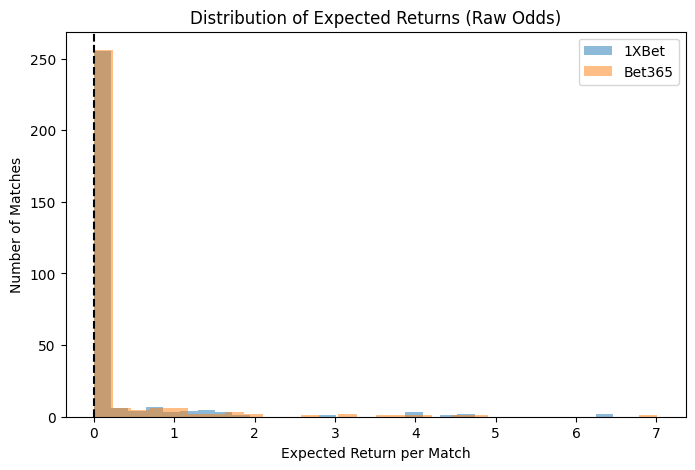

In [88]:
plt.figure(figsize=(8,5))
plt.hist(merged_betting['ExpReturn_1XBet'], bins=30, alpha=0.5, label='1XBet')
plt.hist(merged_betting['ExpReturn_B365'], bins=30, alpha=0.5, label='Bet365')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Expected Return per Match')
plt.ylabel('Number of Matches')
plt.title('Distribution of Expected Returns (Raw Odds)')
plt.legend()
plt.show()


In [ ]:
merged_betting.columns

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       'Diff_Away_1XBet', 'Diff_Home_B365', 'Diff_Draw_B365', 'Diff_Away_B365',
       'Value_Home_1XBet', 'Value_Away_1XBet', 'Value_Draw_1XBet', 'BetSignal',
       'ExpReturn_1XBet', 'ExpReturn_B365'],
      dtype='object', length=172)

In [ ]:
merged.columns

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       'B365_AwayProb', 'Diff_Home_1XBet', 'Diff_Draw_1XBet',
       'Diff_Away_1XBet', 'Diff_Home_B365', 'Diff_Draw_B365', 'Diff_Away_B365',
       'Value_Home_1XBet', 'Value_Away_1XBet', 'Value_Draw_1XBet'],
      dtype='object', length=169)

In [94]:
stake = 10

def compute_returns(merged_betting, book_prefix):
    odds_map = {
        "1XBet": "1XB",
        "B365": "B365"
    }
    odds_prefix = odds_map[book_prefix]
    outcomes = {
        "Home": ("HomeProb",  f"{odds_prefix}H", f"Diff_Home_{book_prefix}"),
        "Draw": ("draw_prob", f"{odds_prefix}D", f"Diff_Draw_{book_prefix}"),
        "Away": ("AwayProb",  f"{odds_prefix}A", f"Diff_Away_{book_prefix}")
    }

    for outcome, (model_col, odds_col, diff_col) in outcomes.items():

        merged_betting[f"Bet_{outcome}_{book_prefix}"] = merged_betting[diff_col] > 0

        merged_betting[f"Profit_{outcome}_{book_prefix}"] = merged_betting.apply(
            lambda row:
                (stake * (row[odds_col] - 1))            
                if (row["FTR"] == outcome[0] and row[f"Bet_{outcome}_{book_prefix}"])
                else (-stake)                            
                if row[f"Bet_{outcome}_{book_prefix}"]
                else 0,                                   
            axis=1
        )
    merged_betting[f"TotalProfit_{book_prefix}"] = (
        merged_betting[f"Profit_Home_{book_prefix}"] +
        merged_betting[f"Profit_Draw_{book_prefix}"] +
        merged_betting[f"Profit_Away_{book_prefix}"]
    )

    return merged_betting

merged_betting = compute_returns(merged_betting, "1XBet")
merged_betting = compute_returns(merged_betting, "B365")

total_profit_1XBet = merged_betting["TotalProfit_1XBet"].sum()
total_profit_B365 = merged_betting["TotalProfit_B365"].sum()

total_bets_1XBet = (
    merged_betting["Bet_Home_1XBet"].sum() +
    merged_betting["Bet_Draw_1XBet"].sum() +
    merged_betting["Bet_Away_1XBet"].sum()
)

total_bets_B365 = (
    merged_betting["Bet_Home_B365"].sum() +
    merged_betting["Bet_Draw_B365"].sum() +
    merged_betting["Bet_Away_B365"].sum()
)

roi_1xbet = total_profit_1XBet / (total_bets_1XBet * stake) if total_bets_1XBet > 0 else 0
roi_b365  = total_profit_B365 / (total_bets_B365 * stake) if total_bets_B365 > 0 else 0


print("1XBet Performance")
print(f"Total Profit: €{total_profit_1XBet:.2f}")
print(f"Total Bets Placed: {total_bets_1XBet}")
print(f"ROI: {roi_1xbet:.2%}\n")

print("=== Bet365 Performance ===")
print(f"Total Profit: €{total_profit_B365:.2f}")
print(f"Total Bets Placed: {total_bets_B365}")
print(f"ROI: {roi_b365:.2%}\n")


1XBet Performance
Total Profit: €98.60
Total Bets Placed: 446
ROI: 2.21%

=== Bet365 Performance ===
Total Profit: €71.50
Total Bets Placed: 445
ROI: 1.61%



In [95]:
import plotly.graph_objects as go

# Create cumulative profit
merged_betting["Cumulative_1XBet"] = merged_betting["TotalProfit_1XBet"].cumsum()
merged_betting["Cumulative_B365"] = merged_betting["TotalProfit_B365"].cumsum()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=merged_betting.index,
    y=merged_betting["Cumulative_1XBet"],
    mode="lines",
    name="1XBet Cumulative Profit"
))

fig.add_trace(go.Scatter(
    x=merged_betting.index,
    y=merged_betting["Cumulative_B365"],
    mode="lines",
    name="Bet365 Cumulative Profit"
))

fig.update_layout(
    title="Cumulative Profit Over Time",
    xaxis_title="Match Index",
    yaxis_title="Profit (€)",
    hovermode="x unified"
)

fig.show()


In [97]:
import plotly.express as px

merged_betting["Edge"] = merged_betting["HomeProb"] - merged_betting["1XBet_HomeProb"]

fig = px.scatter(
    merged_betting,
    x="Edge",
    y="Profit_Home_1XBet",
    title="Model Edge vs Profit (Interactive)",
    trendline="ols",
    hover_data=["HomeTeam", "AwayTeam", "FTR"]
)

fig.show()


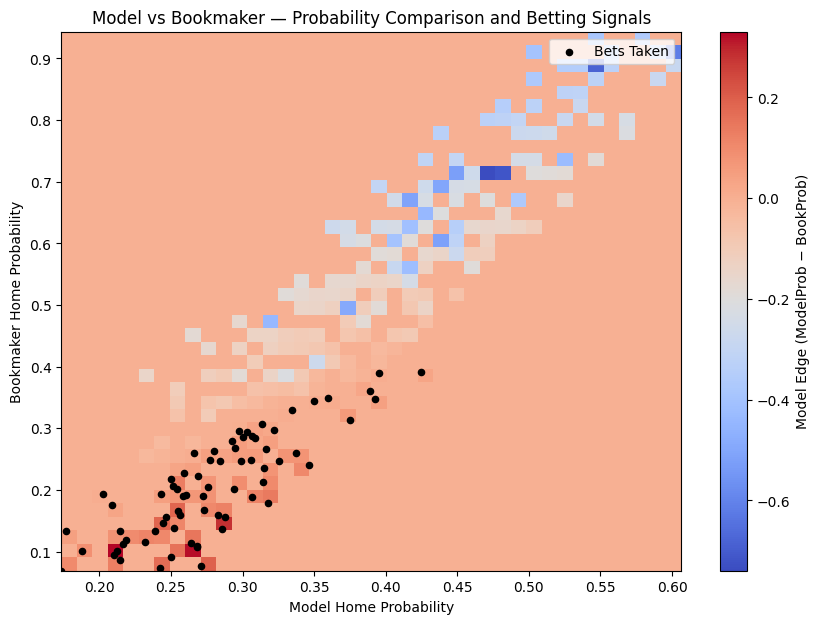

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Extract model vs bookmaker probabilities
model_p = merged_betting["HomeProb"]
book_p = merged_betting["1XBet_HomeProb"]
edge = merged_betting["Diff_Home_1XBet"]

plt.figure(figsize=(10,7))

# Heatmap background using 2D histogram
plt.hist2d(model_p, book_p, bins=40, weights=edge, cmap="coolwarm")

plt.colorbar(label="Model Edge (ModelProb − BookProb)")

# Scatter for actual bets placed
bet_mask = merged_betting["Bet_Home_1XBet"] == True
plt.scatter(
    model_p[bet_mask],
    book_p[bet_mask],
    s=20,
    color="black",
    label="Bets Taken"
)

plt.xlabel("Model Home Probability")
plt.ylabel("Bookmaker Home Probability")
plt.title("Model vs Bookmaker — Probability Comparison and Betting Signals")
plt.legend()
plt.show()
